## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load dataset

In [ ]:
df = pd.read_parquet("data/agricultural_crop_yield.parquet")
df

,farm_id,region,crop_type,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,irrigation_type,...,sowing_date,harvest_date,total_days,sensor_id,timestamp,latitude,longitude,NDVI_index,crop_disease_status,yield
0,FARM0001,North India,Wheat,35.95,5.99,17.79,75.62,77.03,7.27,None,...,2024-01-08,2024-05-09,122,SENS0001,2024-03-19,14.970941,82.997689,0.63,Mild,44080.7
1,FARM0002,South USA,Soybean,19.74,7.24,30.18,89.91,61.13,5.67,Sprinkler,...,2024-02-04,2024-05-26,112,SENS0002,2024-04-21,16.613022,70.869009,0.58,None,53899.8
2,FARM0003,South USA,Wheat,29.32,7.16,27.37,265.43,68.87,8.23,Drip,...,2024-02-03,2024-06-26,144,SENS0003,2024-02-28,19.503156,79.068206,0.80,Mild,29311.6
3,FARM0004,Central USA,Maize,17.33,6.03,33.73,212.01,70.46,5.03,Sprinkler,...,2024-02-21,2024-07-04,134,SENS0004,2024-05-14,31.071298,85.519998,0.44,None,42278.0
4,FARM0005,Central USA,Cotton,19.37,5.92,33.86,269.09,55.73,7.93,None,...,2024-02-05,2024-05-20,105,SENS0005,2024-04-13,16.56854,81.691720,0.84,Severe,49799.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,FARM0496,Central USA,Rice,42.85,6.7,30.85,52.35,79.58,7.25,Manual,...,2024-01-16,2024-06-02,138,SENS0496,2024-05-08,30.386623,76.147700,0.59,Mild,42514.0
496,FARM0497,North India,Soybean,34.22,6.75,17.46,256.23,45.14,5.78,None,...,2024-01-01,2024-04-14,104,SENS0497,2024-01-19,18.832748,75.736924,0.85,Severe,37085.4
497,FARM0498,North India,Cotton,15.93,5.72,17.03,288.96,57.87,7.69,Drip,...,2024-01-02,2024-05-09,128,SENS0498,2024-04-20,23.262016,81.992230,0.71,Mild,26044.1
498,FARM0499,Central USA,Soybean,38.61,6.2,17.08,279.06,73.09,9.60,Drip,...,2024-01-25,2024-06-04,131,SENS0499,2024-03-02,19.764989,84.426869,0.77,Severe,25863.6


In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
df.head()

,farm_id,region,crop_type,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,irrigation_type,fertilizer_type,pesticide_usage_ml,sowing_date,harvest_date,total_days,sensor_id,timestamp,latitude,longitude,NDVI_index,crop_disease_status,yield
0,FARM0001,North India,Wheat,35.95,5.99,17.79,75.62,77.03,7.27,None,Organic,6.34,2024-01-08,2024-05-09,122,SENS0001,2024-03-19,14.970941,82.997689,0.63,Mild,44080.7
1,FARM0002,South USA,Soybean,19.74,7.24,30.18,89.91,61.13,5.67,Sprinkler,Inorganic,9.60,2024-02-04,2024-05-26,112,SENS0002,2024-04-21,16.613022,70.869009,0.58,None,53899.8
2,FARM0003,South USA,Wheat,29.32,7.16,27.37,265.43,68.87,8.23,Drip,Mixed,15.26,2024-02-03,2024-06-26,144,SENS0003,2024-02-28,19.503156,79.068206,0.80,Mild,29311.6
3,FARM0004,Central USA,Maize,17.33,6.03,33.73,212.01,70.46,5.03,Sprinkler,Organic,25.80,2024-02-21,2024-07-04,134,SENS0004,2024-05-14,31.071298,85.519998,0.44,None,42278.0
4,FARM0005,Central USA,Cotton,19.37,5.92,33.86,269.09,55.73,7.93,None,Mixed,25.65,2024-02-05,2024-05-20,105,SENS0005,2024-04-13,16.56854,81.691720,0.84,Severe,49799.6


## Data Understanding and Preprocessing

### Columns in Dataset

In [4]:
df.columns

Index(['farm_id', 'region', 'crop_type', 'soil_moisture_%', 'soil_pH',
       'temperature_C', 'rainfall_mm', 'humidity_%', 'sunlight_hours',
       'irrigation_type', 'fertilizer_type', 'pesticide_usage_ml',
       'sowing_date', 'harvest_date', 'total_days', 'sensor_id', 'timestamp',
       'latitude', 'longitude', 'NDVI_index', 'crop_disease_status', 'yield'],
      dtype='object')

### Check Data Dimension and Data Types

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   farm_id              500 non-null    object 
 1   region               500 non-null    object 
 2   crop_type            500 non-null    object 
 3   soil_moisture_%      500 non-null    float64
 4   soil_pH              500 non-null    object 
 5   temperature_C        500 non-null    float64
 6   rainfall_mm          500 non-null    float64
 7   humidity_%           500 non-null    float64
 8   sunlight_hours       499 non-null    float64
 9   irrigation_type      350 non-null    object 
 10  fertilizer_type      500 non-null    object 
 11  pesticide_usage_ml   500 non-null    float64
 12  sowing_date          500 non-null    object 
 13  harvest_date         500 non-null    object 
 14  total_days           500 non-null    int64  
 15  sensor_id            500 non-null    obj

- Dataset terdiri dari **500 baris dan 22 kolom**.
- Ada **kesalahan tipe data** di **soil_ph** dan **latitude**, yaitu bertipe data object, sedangkan seharusnya bertipe data float.

### Check Duplicate

In [6]:
print("Duplicated Row : " ,df.duplicated().sum())

Duplicated Row :  0


**Tidak ada data duplikat.**

### Check Inconsistent

In [7]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols :
  print("Total Unique Values : ", df[col].nunique())
  print(df[col].value_counts())
  print()

Total Unique Values :  500
farm_id
FARM0500    1
FARM0001    1
FARM0002    1
FARM0003    1
FARM0484    1
           ..
FARM0009    1
FARM0008    1
FARM0007    1
FARM0006    1
FARM0005    1
Name: count, Length: 500, dtype: int64

Total Unique Values :  5
region
Central USA    109
East Africa    107
North India     99
South USA       94
South India     91
Name: count, dtype: int64

Total Unique Values :  5
crop_type
Maize      111
Soybean    108
Cotton     107
Wheat       92
Rice        82
Name: count, dtype: int64

Total Unique Values :  186
soil_pH
5.97    7
6.33    7
7.3     6
6.78    6
6.3     6
       ..
6.47    1
6,42    1
7.08    1
5.82    1
6.71    1
Name: count, Length: 186, dtype: int64

Total Unique Values :  3
irrigation_type
Sprinkler    121
Manual       118
Drip         111
Name: count, dtype: int64

Total Unique Values :  3
fertilizer_type
Inorganic    167
Mixed        167
Organic      166
Name: count, dtype: int64

Total Unique Values :  84
sowing_date
2024-03-05    15
20

Di **soil_ph** terdapat nilai **6,42** -> penyebab bertipe data object. Dan mungkin hal ini juga yang terjadi di **latitude**, hanya saja tidak terlihat di cek inconsistent ini.

### Handling Inconsistent and Data Types

In [8]:
df['soil_pH'] = df['soil_pH'].astype(str).str.replace(',', '.')
df['soil_pH'] = pd.to_numeric(df['soil_pH'], errors='coerce')

df['latitude'] = df['latitude'].astype(str).str.replace(',', '.')
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')

In [9]:
df['sowing_date'] = pd.to_datetime(df['sowing_date'])
df['harvest_date'] = pd.to_datetime(df['harvest_date'])
df['timestamp'] = pd.to_datetime(df['timestamp'])

- Menghandle fitur yang tidak konsisten (mengandung koma) yang juga menjadi penyebab ketidaksesuaian pada data type.
- Melakukan perubahan data types untuk fitur yang masih belum sesuai

### Check Invalid Values

In [10]:
df.describe()

,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,pesticide_usage_ml,sowing_date,harvest_date,total_days,timestamp,latitude,longitude,NDVI_index,yield
count,500.000000,500.000000,500.000000,500.000000,500.000000,499.000000,500.000000,500,500,500.000000,500,498.000000,500.000000,500.000000,500.000000
mean,26.750140,6.523980,24.675740,181.685740,65.194460,7.031904,26.586980,2024-02-15 05:42:43.199999744,2024-06-13 17:36:57.599999744,119.114000,2024-04-14 17:42:43.200000256,22.464064,80.392248,0.602060,40329.269400
min,10.160000,5.510000,15.000000,50.170000,40.230000,4.010000,5.050000,2024-01-01 00:00:00,2024-04-09 00:00:00,-50.000000,2024-01-03 00:00:00,10.004243,70.020021,0.300000,20235.600000
25%,17.890000,6.030000,20.295000,119.217500,51.865000,5.665000,14.945000,2024-01-23 00:00:00,2024-05-24 00:00:00,105.000000,2024-03-12 00:00:00,16.274905,75.374713,0.447500,29948.200000
50%,25.855000,6.530000,24.655000,191.545000,65.685000,7.000000,25.980000,2024-02-16 00:00:00,2024-06-14 00:00:00,118.500000,2024-04-14 00:00:00,22.032474,80.650284,0.610000,40716.900000
75%,36.022500,7.040000,29.090000,239.035000,77.995000,8.470000,38.005000,2024-03-09 00:00:00,2024-07-06 06:00:00,134.000000,2024-05-18 06:00:00,28.557783,85.654629,0.750000,50621.100000
max,44.980000,7.500000,34.840000,298.960000,90.000000,10.000000,49.940000,2024-03-28 00:00:00,2024-08-17 00:00:00,150.000000,2024-08-12 00:00:00,34.981531,89.991901,0.900000,59982.900000
std,10.150053,0.585558,5.348899,72.293091,14.642849,1.692908,13.202429,NaN,NaN,18.403107,NaN,7.285843,5.910664,0.175402,11744.330399


Ada invalid values di **total_days**, terdapat nilai -50 yang tidak masuk akal (total hari tidak mungkin negatif)

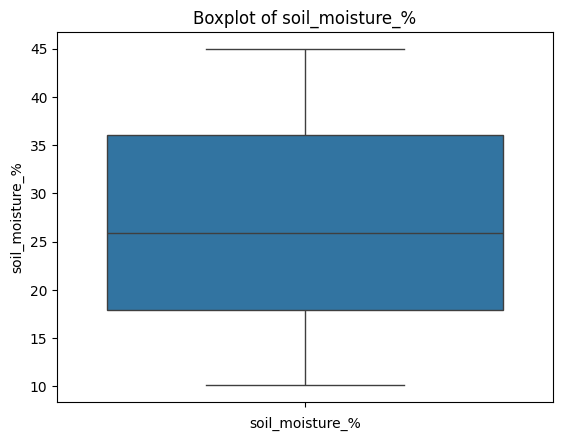

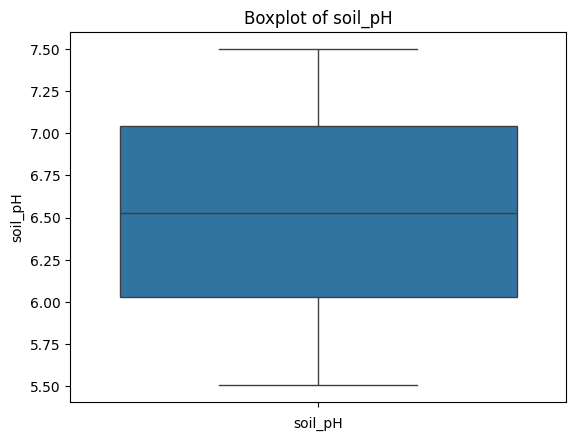

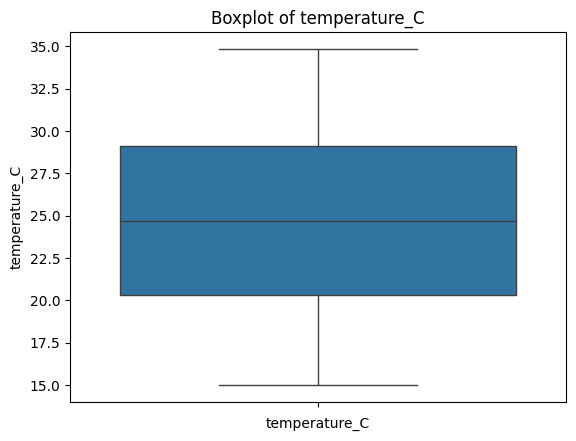

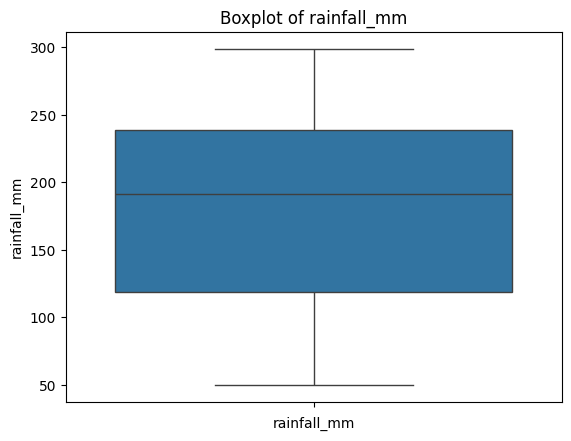

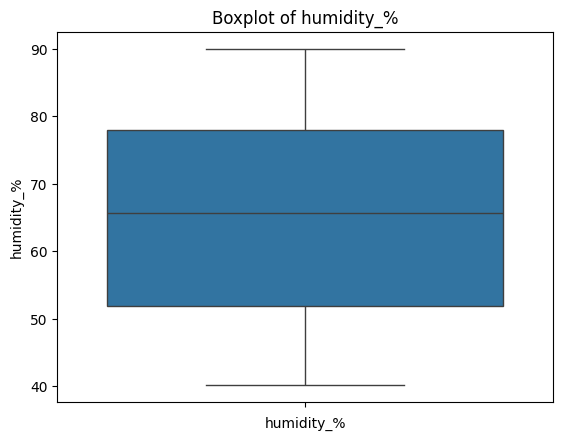

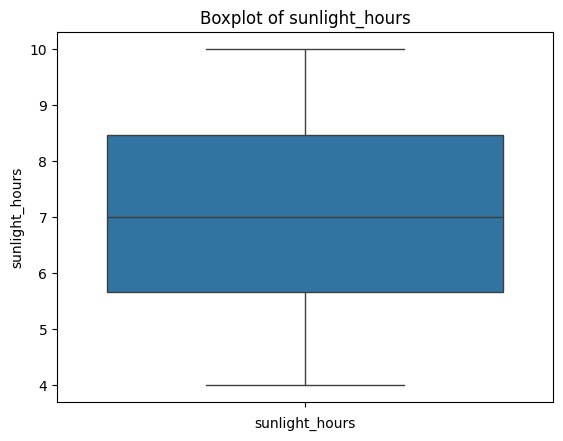

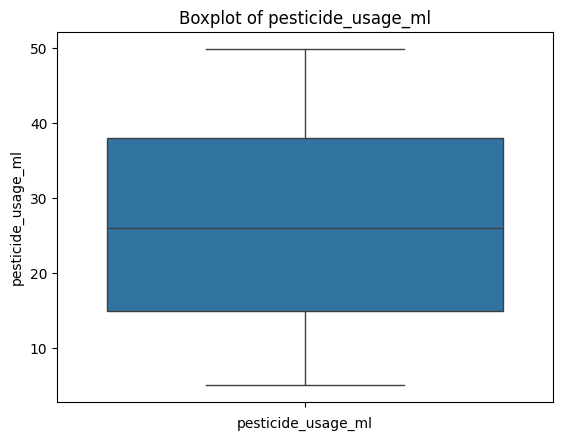

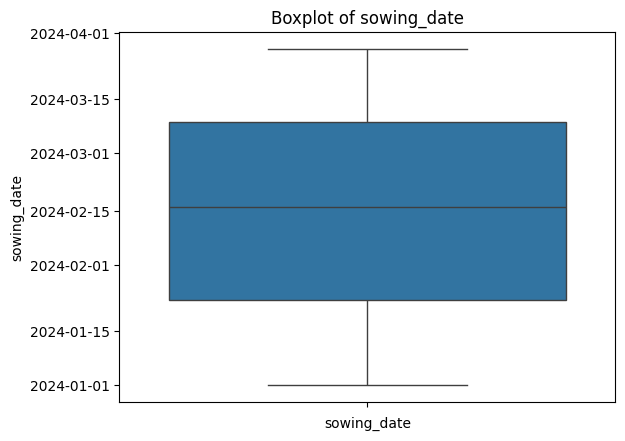

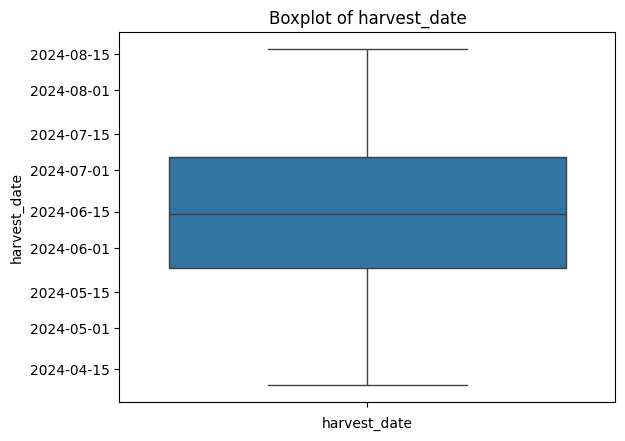

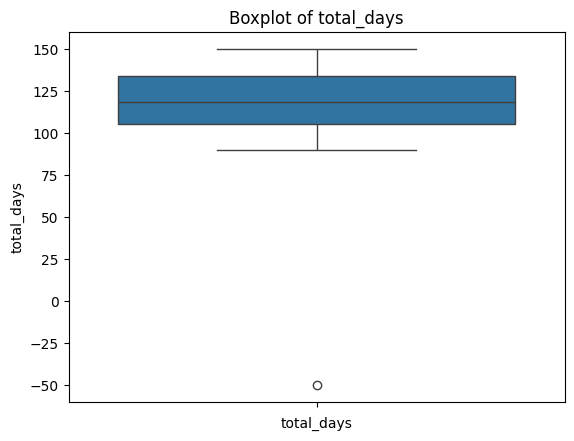

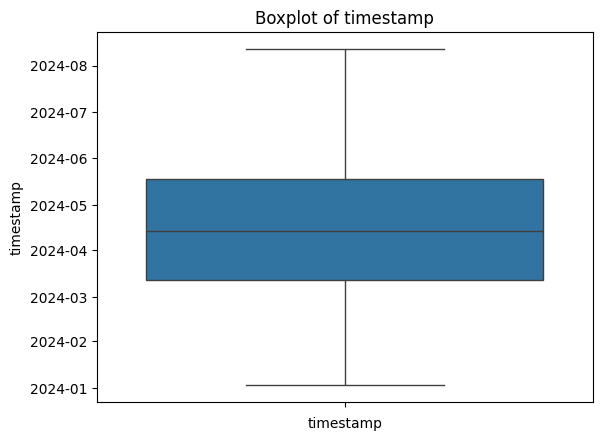

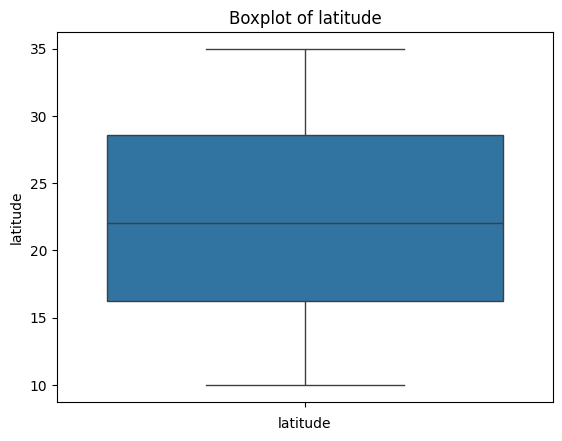

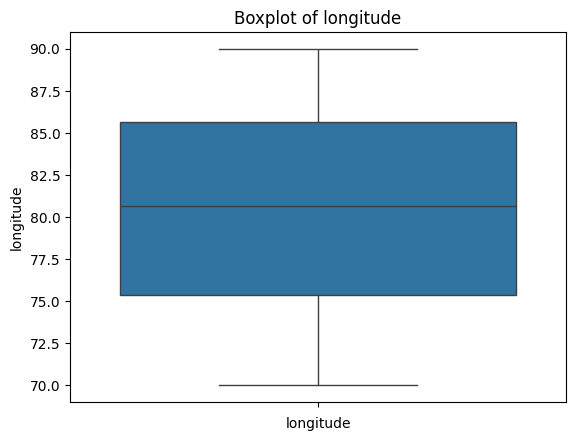

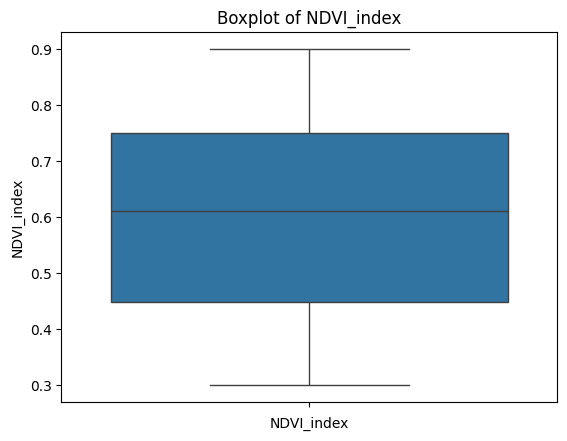

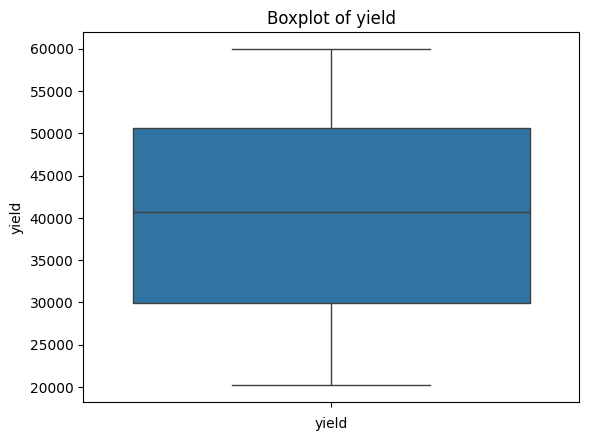

In [11]:
num_cols = df.select_dtypes(exclude=['object']).columns

for col in num_cols :
  sns.boxplot(y = df[col])
  plt.title(f'Boxplot of {col}')
  plt.xlabel(col)
  plt.show()

### Handling Invalid Values

In [12]:
df.loc[df['total_days'] < 0, 'total_days'] = np.nan

### Check Missing Values

In [13]:
df.isnull().sum()

farm_id                  0
region                   0
crop_type                0
soil_moisture_%          0
soil_pH                  0
temperature_C            0
rainfall_mm              0
humidity_%               0
sunlight_hours           1
irrigation_type        150
fertilizer_type          0
pesticide_usage_ml       0
sowing_date              0
harvest_date             0
total_days               1
sensor_id                0
timestamp                0
latitude                 2
longitude                0
NDVI_index               0
crop_disease_status    130
yield                    0
dtype: int64

### Handling Meaningless Features

In [14]:
df = df.drop(columns=["farm_id", "sensor_id"])

### Feature Engineering

In [15]:
df['sowing_month'] = df['sowing_date'].dt.month
df['harvest_month'] = df['harvest_date'].dt.month
df['timestamp_month'] = df['timestamp'].dt.month

In [16]:
df.drop(['sowing_date', 'harvest_date', 'timestamp'], axis=1, inplace=True)

## EDA

### Distribution

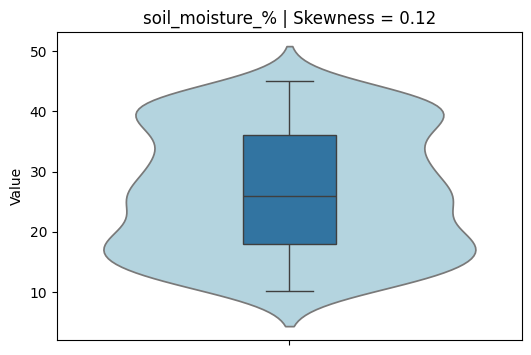

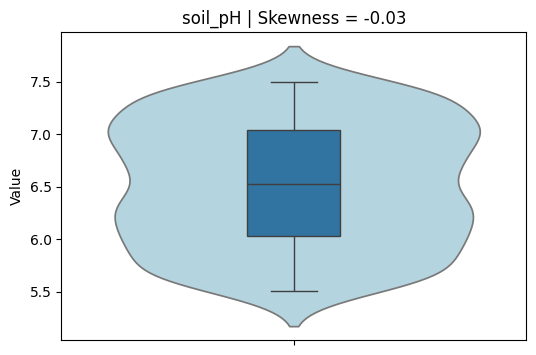

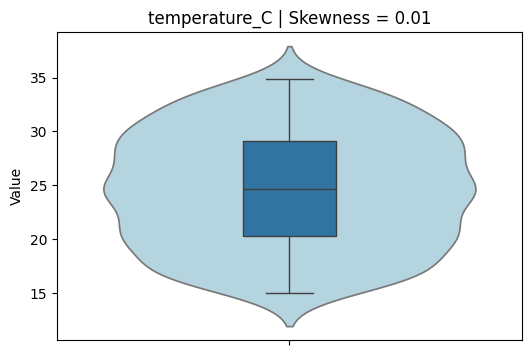

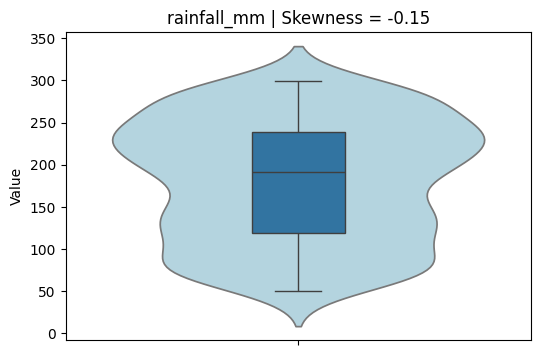

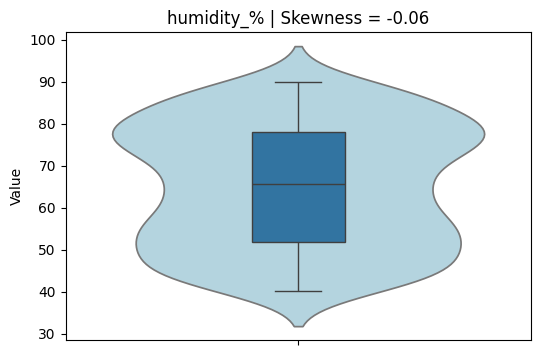

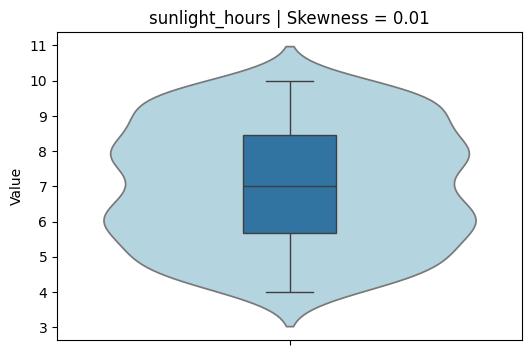

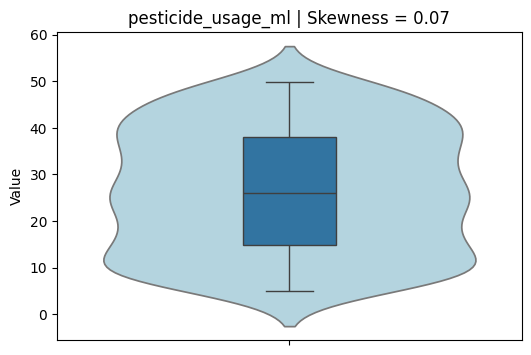

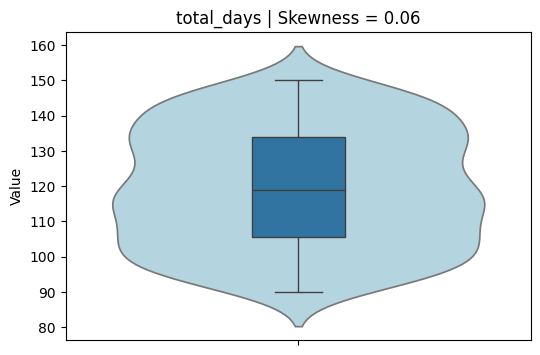

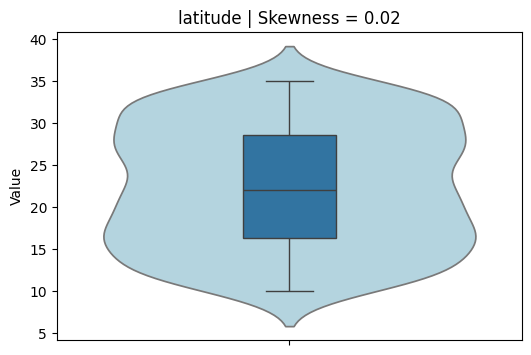

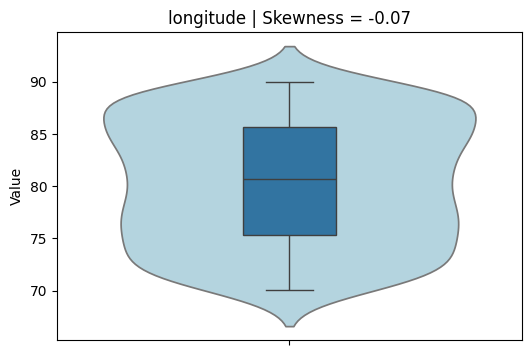

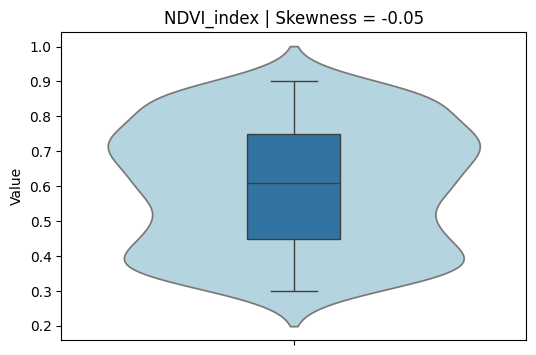

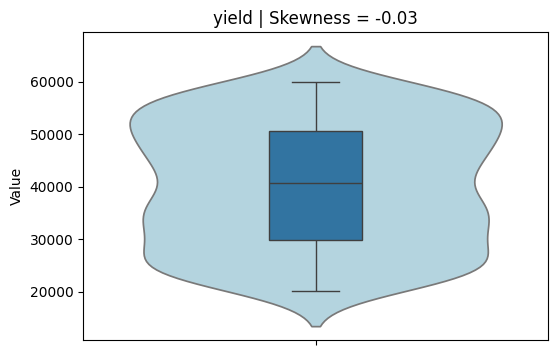

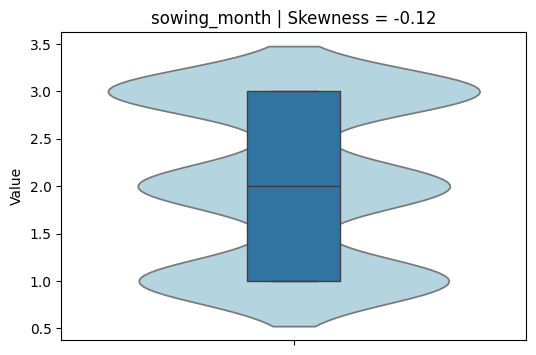

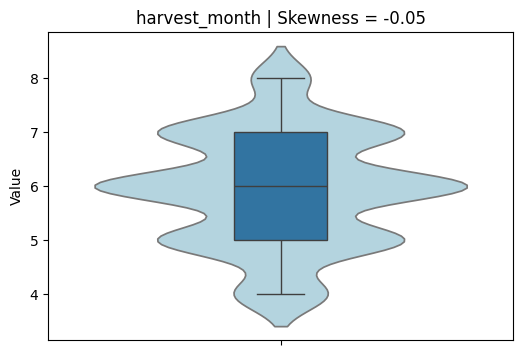

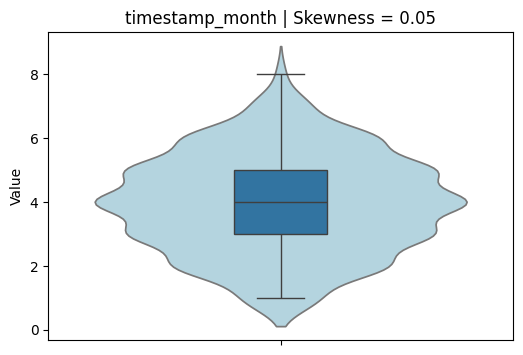

In [17]:
num_cols = df.select_dtypes(exclude=['object']).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.violinplot(y=df[col], inner=None, color="lightblue")
    sns.boxplot(y=df[col], width=0.2)
    plt.title(f"{col} | Skewness = {df[col].skew():.2f}")
    plt.ylabel("Value")
    plt.show()

Tidak ada fitur yang mengandung skewed esktrem dan secara keseluruhan  berdistribusi normal.

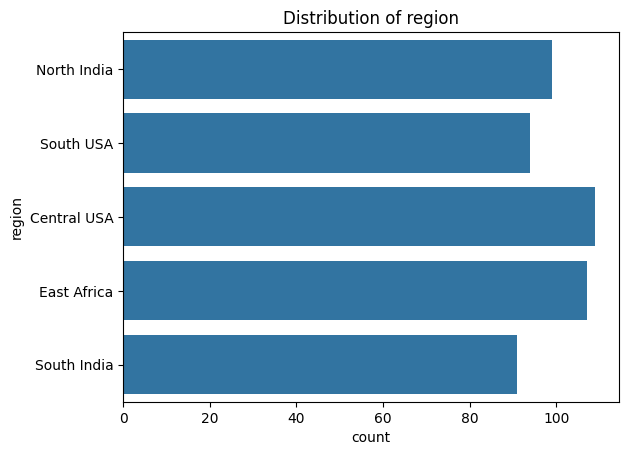

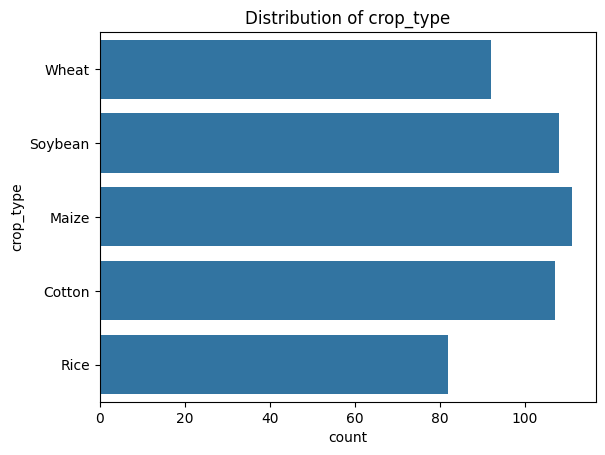

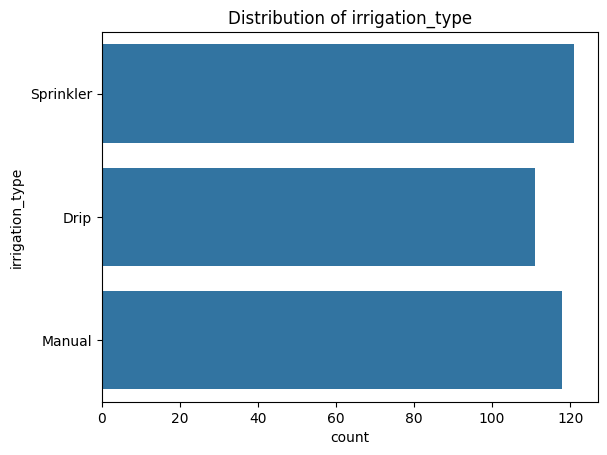

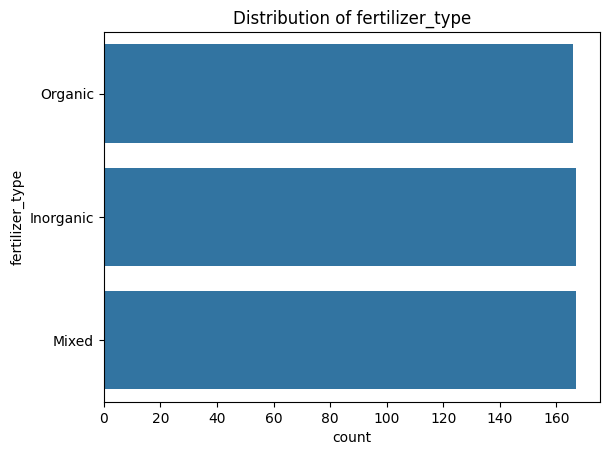

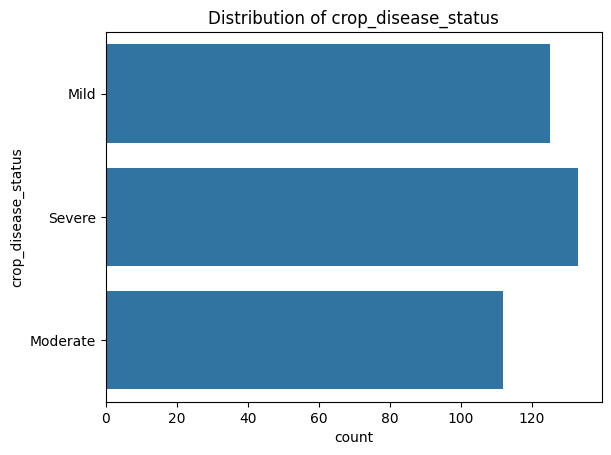

In [18]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    sns.countplot(data=df, y=col)
    plt.title(f'Distribution of {col}')
    plt.show()

### Correlation

#### Between Numerical Variables

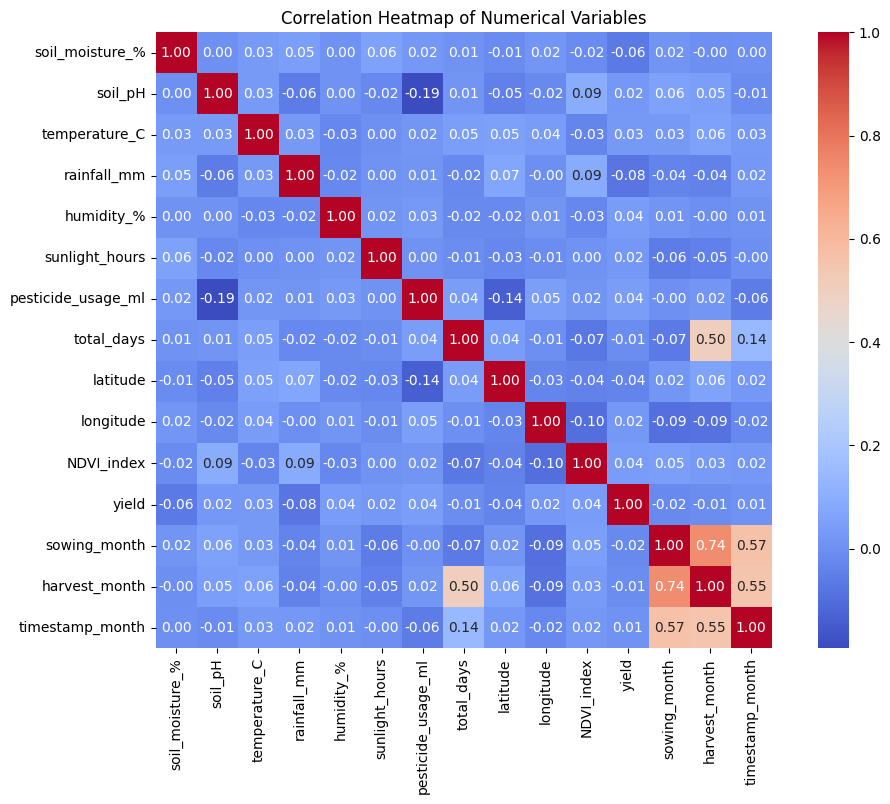

In [19]:
num_cols = df.select_dtypes(exclude=['object'])

corr_matrix = num_cols.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot = True, fmt = ".2f", cmap = "coolwarm", square=True)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

In [20]:
df['sowing_month_sin'] = np.sin(2 * np.pi * df['sowing_month']/12)
df['sowing_month_cos'] = np.cos(2 * np.pi * df['sowing_month']/12)

df.drop(['sowing_month', 'harvest_month', 'timestamp_month'], axis=1, inplace=True)

Berdasarkan analisis korelasi, fitur harvest_month dan timestamp_month dihapus karena memiliki korelasi tinggi dengan fitur lain dan tidak memberikan informasi tambahan yang signifikan. Sementara itu, fitur sowing_month dipertahankan dan ditransformasikan menggunakan cyclic encoding untuk menangkap pola musiman secara lebih akurat. Fitur total_days tetap digunakan karena merepresentasikan durasi pertumbuhan tanaman yang relevan terhadap hasil panen.

#### Between Categorical Variables and Target Variables

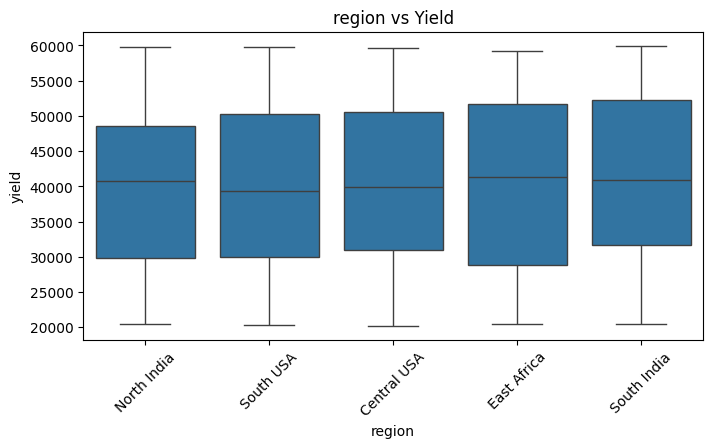

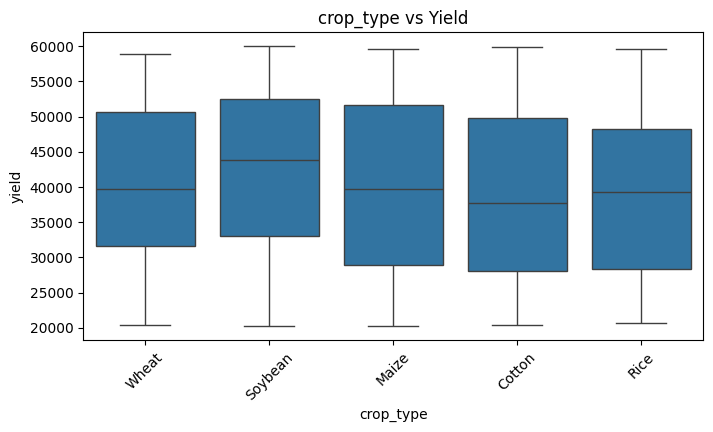

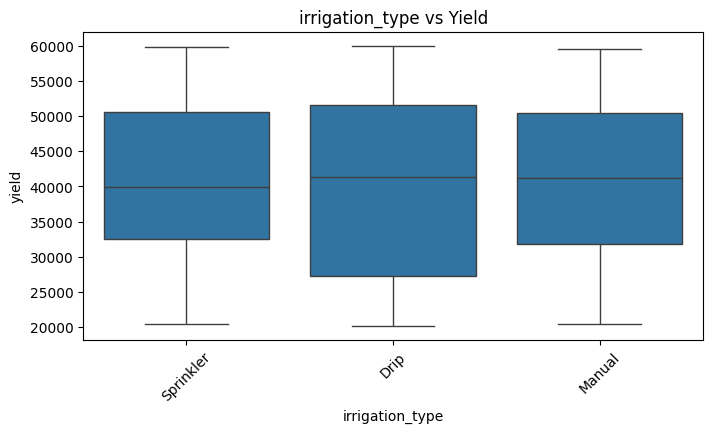

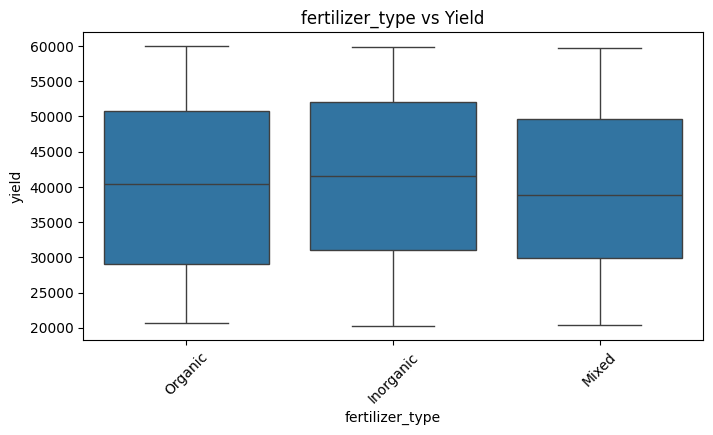

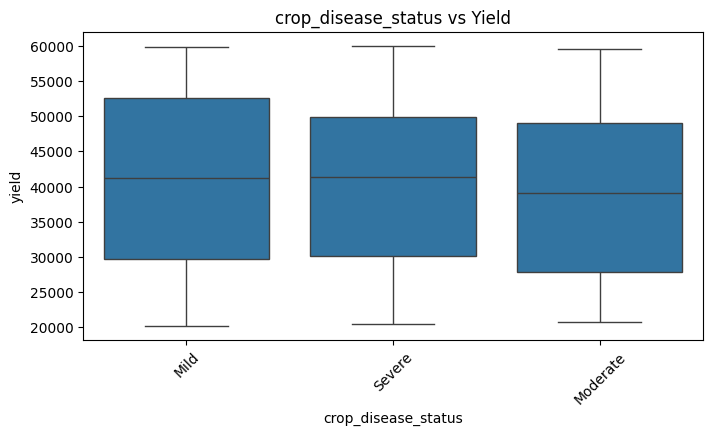

In [21]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col], y=df['yield'])
    plt.title(f'{col} vs Yield')
    plt.xticks(rotation=45)
    plt.show()

Di bagian region, terlihat **South India** yang memiliki nilai **yield** tertinggi.
Untuk **crop_type**, **soybean** memiliki nilai yield tertinggi, serta untuk **crop_disease_status** terlihat **mild** memiliki nilai yang paling besar diantara nilai crop_disease_status lainnya. Tapi perbedaan nilai dalam setiap kategori tidak terlalu jauh berbeda atau masih memiliki distribusi yang cukup mirip.


#### Between Categorical Variables

In [22]:
for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        col1 = cat_cols[i]
        col2 = cat_cols[j]

        print(f"\n=== Normalized Crosstab: {col1} vs {col2} ===")
        print(pd.crosstab(df[col1], df[col2], normalize='index'))


=== Normalized Crosstab: region vs crop_type ===
crop_type      Cotton     Maize      Rice   Soybean     Wheat
region                                                       
Central USA  0.238532  0.192661  0.165138  0.247706  0.155963
East Africa  0.224299  0.224299  0.186916  0.224299  0.140187
North India  0.181818  0.242424  0.191919  0.181818  0.202020
South India  0.219780  0.230769  0.076923  0.241758  0.230769
South USA    0.202128  0.223404  0.191489  0.180851  0.202128

=== Normalized Crosstab: region vs irrigation_type ===
irrigation_type      Drip    Manual  Sprinkler
region                                        
Central USA      0.350000  0.325000   0.325000
East Africa      0.311688  0.402597   0.285714
North India      0.306452  0.370968   0.322581
South India      0.285714  0.317460   0.396825
South USA        0.323529  0.264706   0.411765

=== Normalized Crosstab: region vs fertilizer_type ===
fertilizer_type  Inorganic     Mixed   Organic
region                      

Secara umum, hubungan antar variabel kategorikal menunjukkan **distribusi yang relatif seimbang** tanpa adanya dominasi yang sangat kuat. Namun, terdapat beberapa pola seperti **hubungan antara jenis tanaman dengan metode irigasi dan jenis pupuk**. Selain itu, terdapat indikasi bahwa **jenis tanaman memiliki pengaruh terhadap tingkat penyakit tanaman**.

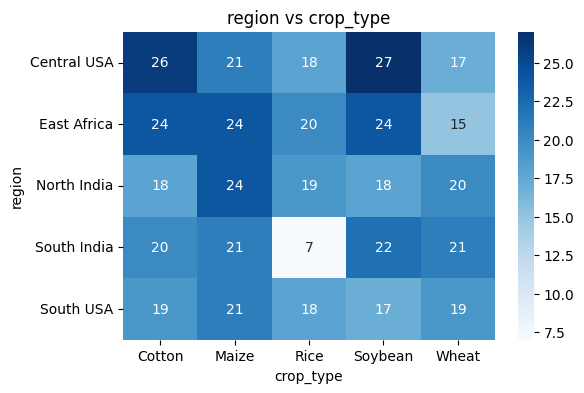

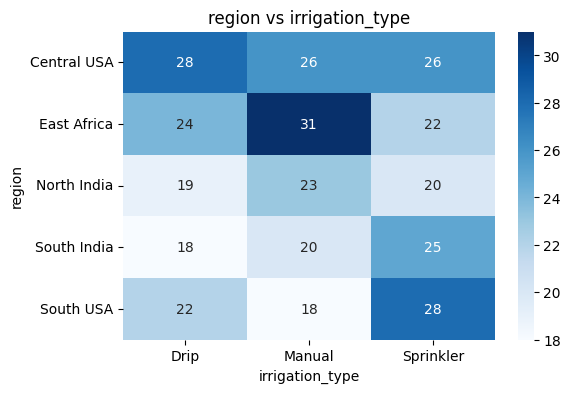

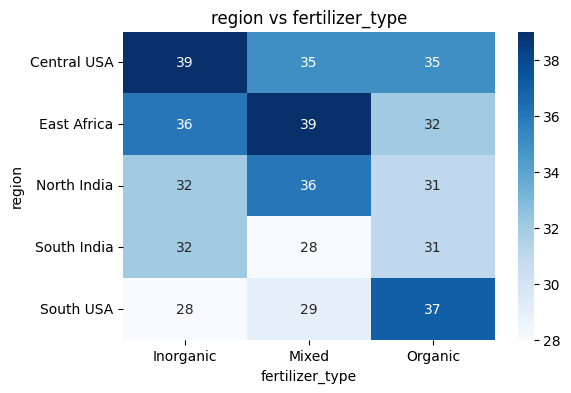

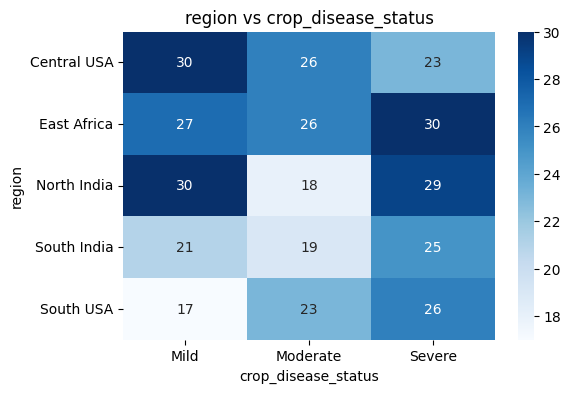

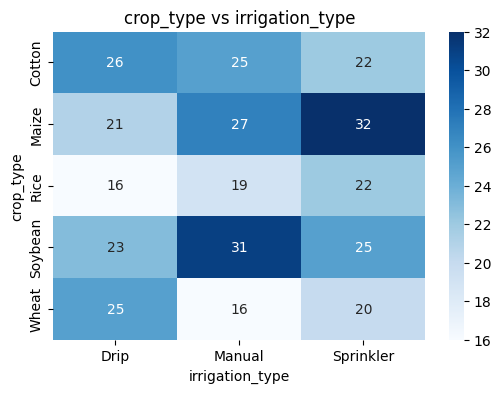

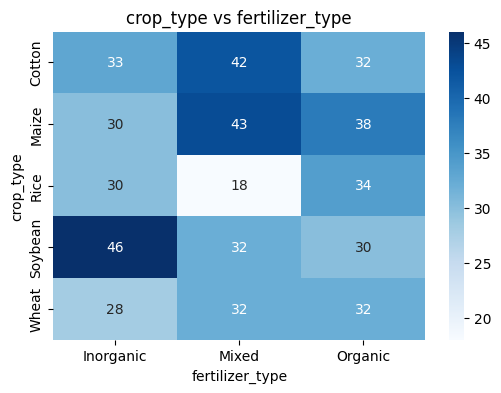

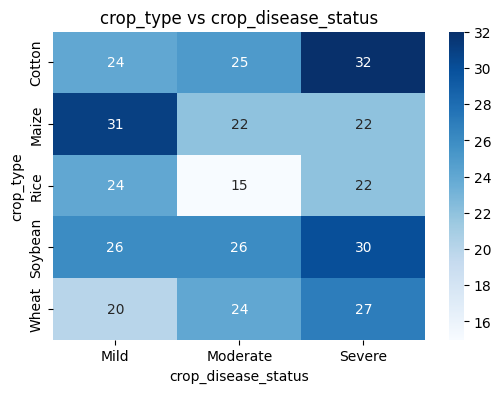

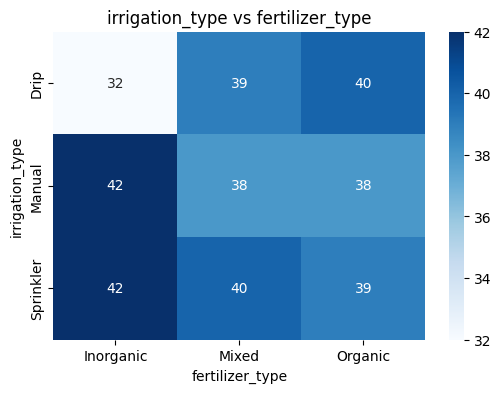

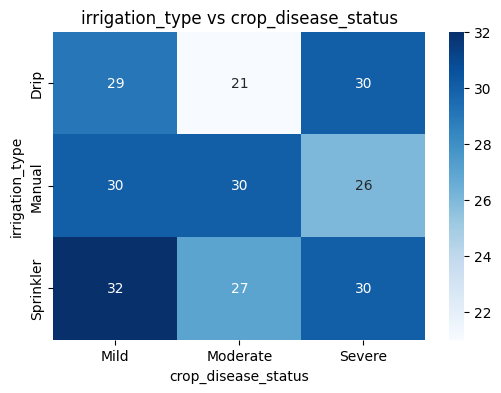

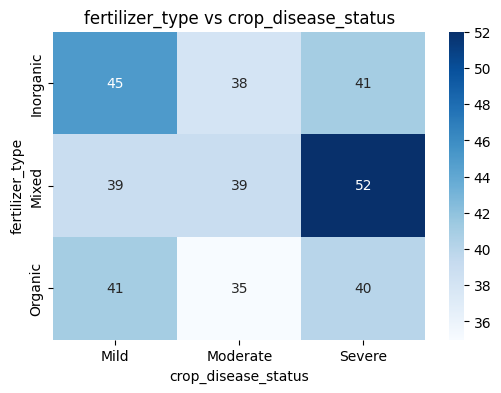

In [23]:
for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        col1 = cat_cols[i]
        col2 = cat_cols[j]

        ct = pd.crosstab(df[col1], df[col2])

        plt.figure(figsize=(6,4))
        sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
        plt.title(f'{col1} vs {col2}')
        plt.show()

## Splitting Data

In [24]:
x = df.drop('yield', axis=1)
y = df['yield']

In [25]:
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.3, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=2/3, random_state=42)

print(x_train.shape,y_train.shape)
print(x_val.shape,y_val.shape)
print(x_test.shape,y_test.shape)

(350, 18) (350,)
(50, 18) (50,)
(100, 18) (100,)


In [26]:
x_train.head()

,region,crop_type,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,irrigation_type,fertilizer_type,pesticide_usage_ml,total_days,latitude,longitude,NDVI_index,crop_disease_status,sowing_month_sin,sowing_month_cos
5,Central USA,Rice,44.91,5.78,24.87,238.95,83.06,4.92,Sprinkler,Mixed,24.00,114.0,23.227859,89.421568,0.82,None,0.500000,8.660254e-01
116,South India,Soybean,35.35,6.62,24.59,267.37,56.65,9.74,Drip,Organic,47.17,137.0,32.861032,83.912526,0.72,Severe,1.000000,6.123234e-17
45,Central USA,Soybean,19.35,5.51,29.52,259.37,69.00,7.96,Sprinkler,Inorganic,29.24,125.0,21.383615,76.435547,0.41,Mild,0.866025,5.000000e-01
16,Central USA,Maize,31.17,6.94,19.07,208.56,53.20,6.93,Drip,Organic,33.54,90.0,25.927834,75.239105,0.74,Severe,0.866025,5.000000e-01
462,South USA,Cotton,20.47,7.13,33.25,89.80,41.08,6.35,None,Mixed,26.30,115.0,28.168865,75.647282,0.85,Severe,0.866025,5.000000e-01


## Handling Missing Values

In [27]:
num_cols = x_train.select_dtypes(exclude=['object']).columns

for col in num_cols:
    median = x_train[col].median()
    x_train[col].fillna(median, inplace=True)
    x_val[col].fillna(median, inplace=True)
    x_test[col].fillna(median, inplace=True)

C:\Users\Felice\AppData\Local\Temp\ipykernel_26148\3484462097.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_train[col].fillna(median, inplace=True)
C:\Users\Felice\AppData\Local\Temp\ipykernel_26148\3484462097.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

In [28]:
cat_cols = x_train.select_dtypes(include=['object']).columns

for col in cat_cols:
    x_train[col].fillna('Unknown', inplace=True)
    x_val[col].fillna('Unknown', inplace=True)
    x_test[col].fillna('Unknown', inplace=True)

C:\Users\Felice\AppData\Local\Temp\ipykernel_26148\1748060692.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_train[col].fillna('Unknown', inplace=True)
C:\Users\Felice\AppData\Local\Temp\ipykernel_26148\1748060692.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

Karena missing value cukup besar, sehingga diinput tidak menggunakan modus, melainkan menggunakan 'Unknown'.

## Encoding

In [29]:
x_train = pd.get_dummies(x_train, drop_first=True)
x_val = pd.get_dummies(x_val, drop_first=True)
x_test = pd.get_dummies(x_test, drop_first=True)

In [30]:
x_val = x_val.reindex(columns=x_train.columns, fill_value=0)
x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

##  Scaling

In [31]:
scaler_x = StandardScaler()

x_train = scaler_x.fit_transform(x_train)
x_val = scaler_x.transform(x_val)
x_test = scaler_x.transform(x_test)

In [32]:
scaler_y = StandardScaler()

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_val_scaled = scaler_y.transform(y_val.values.reshape(-1,1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1,1))

## Baseline Model

C:\Users\Felice\anaconda3\envs\deep-learning\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 58)                  │           1,740 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 58)                  │           3,422 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              59 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,221 (20.39 KB)

 Trainable params: 5,221 (20.39 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 1.1672 - mae: 0.9311 - root_mean_squared_error: 1.0804 - val_loss: 1.1053 - val_mae: 0.9269 - val_root_mean_squared_error: 1.0513
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9959 - mae: 0.8593 - root_mean_squared_error: 0.9979 - val_loss: 1.1469 - val_mae: 0.9269 - val_root_mean_squared_error: 1.0709
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9152 - mae: 0.8254 - root_mean_squared_error: 0.9567 - val_loss: 1.1797 - val_mae: 0.9386 - val_root_mean_squared_error: 1.0861
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8556 - mae: 0.7930 - root_mean_squared_error: 0.9250 - val_loss: 1.1351 - val_mae: 0.9305 - val_root_mean_squared_error: 1.0654
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8104 - mae: 0.7721 - root_mean_squared_error: 0.9002 - val_loss: 1.1653 - val_mae: 0.9380 - val_root_mean_squared_error: 1.0795
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0

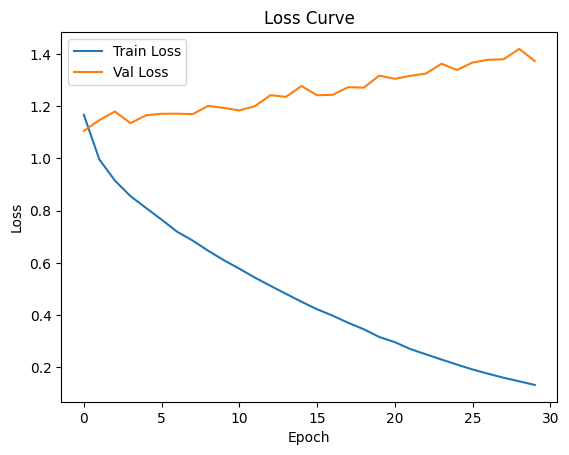

In [33]:
batch_size = 32

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train_scaled)).shuffle(len(x_train)).batch(batch_size)
val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val_scaled)).batch(batch_size)
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test_scaled)).batch(batch_size)

input_dim = x_train.shape[1]

baseline_model = Sequential([Dense(input_dim * 2, activation="relu", input_shape=(input_dim,)),
                    Dense(input_dim * 2, activation="relu"),
                    Dense(1, activation="linear")])

baseline_model.compile(optimizer='adam', loss='mse', metrics=['mae', tf.keras.metrics.RootMeanSquaredError()])

baseline_model.summary()

history_base = baseline_model.fit(train_ds, validation_data=val_ds, epochs=30)

plt.plot(history_base.history['loss'], label='Train Loss')
plt.plot(history_base.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Model baseline menunjukkan **penurunan loss yang signifikan pada data training**, namun **validation loss cenderung meningkat**, yang mengindikasikan terjadinya **overfitting**. Nilai **R² negatif** menunjukkan bahwa performa model lebih buruk dibandingkan model sederhana (mean prediction), yang mengindikasikan bahwa hubungan antara fitur dan target **sangat lemah**. Oleh karena itu, model baseline ini masih perlu ditingkatkan performanya melalui teknik regularisasi, feature engineering tambahan, atau tuning arsitektur model.

## Modified Baseline Model

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 1.4274 - mae: 1.0056 - root_mean_squared_error: 1.1947 - val_loss: 1.0997 - val_mae: 0.9311 - val_root_mean_squared_error: 1.0487 - learning_rate: 0.0010
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.2885 - mae: 0.9587 - root_mean_squared_error: 1.1351 - val_loss: 1.1161 - val_mae: 0.9345 - val_root_mean_squared_error: 1.0565 - learning_rate: 0.0010
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2729 - mae: 0.9638 - root_mean_squared_error: 1.1283 - val_loss: 1.1196 - val_mae: 0.9379 - val_root_mean_squared_error: 1.0581 - learning_rate: 0.0010
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.1986 - mae: 0.9354 - root_mean_squared_error: 1.0948 - val_loss: 1.1140 - val_mae: 0.9356 - val_root_mean_squared_error: 1.0554 - learning_rate: 0.0010
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.1388 - mae: 0.9132 - root_mean_squared_error: 1.0672 - val_loss: 1.1141 - val_mae: 0.9351 - val_

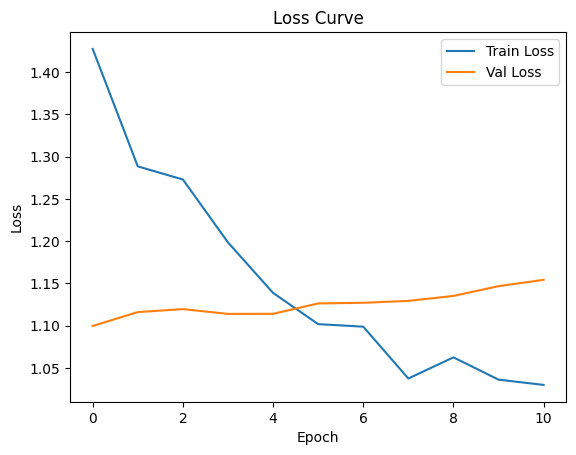

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
=== Improved Model Evaluation ===
MAE  : 11027.885417968748
RMSE : 13034.550348932158
R2   : -0.21201575788380822


In [35]:
batch_size = 64

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train_scaled)).shuffle(len(x_train)).batch(batch_size)
val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val_scaled)).batch(batch_size)
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test_scaled)).batch(batch_size)

model_improved = Sequential([Input(shape=(input_dim,)),
                             Dense(32, activation='relu'),
                             Dropout(0.1),
                             Dense(16, activation='relu'),
                             Dense(1, activation='linear')])

model_improved.compile(optimizer=Adam(learning_rate=0.001), 
                       loss='mse', 
                       metrics=['mae', tf.keras.metrics.RootMeanSquaredError()])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

history_improved = model_improved.fit(train_ds,
                                      validation_data=val_ds,
                                      epochs=100,
                                      callbacks=[early_stop, reduce_lr],
                                      verbose=1)

plt.plot(history_improved.history['loss'], label='Train Loss')
plt.plot(history_improved.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Modifikasi yang dilakukan :    
- **Pengurangan jumlah neuron**   
  Dari 2×dimensi input menjadi 32 dan 16 neuron
  Bertujuan untuk menyederhanakan model agar tidak overfitting
- **Penambahan Dropout (0.1)**   
  Untuk mencegah model terlalu bergantung pada neuron tertentu dan membantu meningkatkan generalisasi
- **Early Stopping**   
  Bertujuan untuk menghentikan training saat performa validation tidak meningkat dan menghindari overfitting akibat training terlalu lama
- **Reduce Learning Rate**   
  Untuk menurunkan learning rate saat model stagnan dan membantu model menemukan minimum loss yang lebih optimal
- **Perubahan batch size**
  Dari 32 ke 64 untuk training lebih stabil

Meskipun **terjadi peningkatan performa, model masih belum optimal**.
Performa model yang kurang optimal menunjukkan bahwa : 
- Sebagian besar fitur memiliki korelasi rendah terhadap target
- Dataset kemungkinan mengandung noise tinggi
- Informasi yang tersedia tidak cukup untuk prediksi akurat

Sehingga menyebabkan model sulit menemukan pola yang kuat dan hyperparameter tuning tidak memberikan peningkatan signifikan

## Evaluation Model

In [42]:
y_pred_base_scaled = baseline_model.predict(x_test)
y_pred_base = scaler_y.inverse_transform(y_pred_base_scaled)

y_true = y_test

mae_base = mean_absolute_error(y_true, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_true, y_pred_base))
r2_base = r2_score(y_true, y_pred_base)

print("=== Baseline Model Evaluation ===")
print("MAE  :", mae_base)
print("RMSE :", rmse_base)
print("R2   :", r2_base)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
=== Baseline Model Evaluation ===
MAE  : 11441.500146484375
RMSE : 14093.374800278816
R2   : -0.41692271247567003


In [43]:
y_pred_imp_scaled = model_improved.predict(test_ds)
y_pred_imp = scaler_y.inverse_transform(y_pred_imp_scaled)

y_true = scaler_y.inverse_transform(y_test_scaled)

mae_imp = mean_absolute_error(y_true, y_pred_imp)
rmse_imp = np.sqrt(mean_squared_error(y_true, y_pred_imp))
r2_imp = r2_score(y_true, y_pred_imp)

print("=== Improved Model Evaluation ===")
print("MAE  :", mae_imp)
print("RMSE :", rmse_imp)
print("R2   :", r2_imp)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
=== Improved Model Evaluation ===
MAE  : 11027.885417968748
RMSE : 13034.550348932158
R2   : -0.21201575788380822


In [44]:
print(f"{'Model':<15}{'MAE':<15}{'RMSE':<15}{'R2'}")
print(f"{'Baseline':<15}{mae_base:<15.2f}{rmse_base:<15.2f}{r2_base:.4f}")
print(f"{'Improved':<15}{mae_imp:<15.2f}{rmse_imp:<15.2f}{r2_imp:.4f}")

Model          MAE            RMSE           R2
Baseline       11441.50       14093.37       -0.4169
Improved       11027.89       13034.55       -0.2120


Hasil Perbandingan :   
- **MAE** (Mean Absolute Error) -> mengukur rata-rata selisih absolut antara nilai prediksi dan nilai aktual (semakin kecil -> semakin baik).
  Nilai MAE pada improved model terjadi penurunan sekitar 400. Sehingga model improved lebih akurat dalam prediksi rata-rata.
- **RMSE** (Root Mean Squared Error) -> mirip MAE, namun lebih sensitif terhadap error besar (semakin kecil -> semakin baik).
  Pada model improved turun cukup signifikan sekitar 1000, ini menunjukkan model improved lebih baik dalam menangani error besar.
- **R^2** -> mengukur seberapa baik model menjelaskan variansi data. Model improved lebih baik dalam menjelaskan pola data dibanding baseline. Namun nilai masih negatif, sehingga model belum mampu menangkap hubungan fitur dengan target dengan baik.

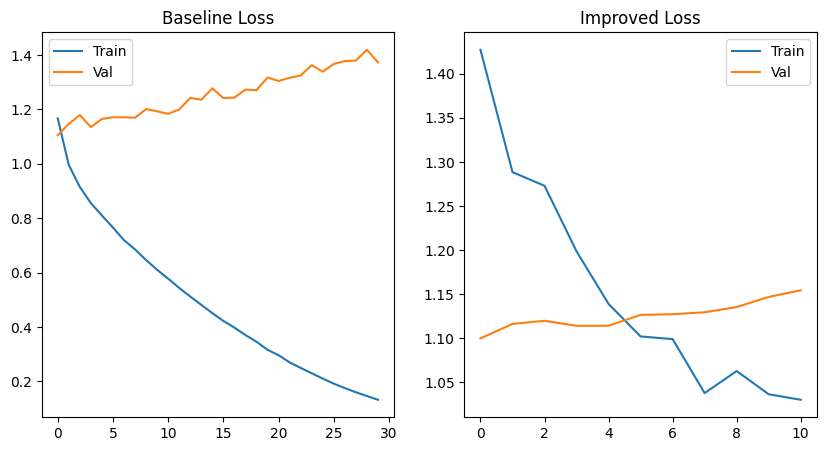

In [45]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(history_base.history['loss'], label='Train')
plt.plot(history_base.history['val_loss'], label='Val')
plt.title("Baseline Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_improved.history['loss'], label='Train')
plt.plot(history_improved.history['val_loss'], label='Val')
plt.title("Improved Loss")
plt.legend()

plt.show()

Berdasarkan hasil evaluasi menggunakan MAE, RMSE, dan R², **model improved menunjukkan performa yang lebih baik dibandingkan baseline model**. Hal ini ditunjukkan oleh **penurunan nilai MAE dan RMSE**, yang berarti kesalahan prediksi model menjadi lebih kecil. Selain itu, nilai R² yang lebih tinggi (meskipun masih negatif) menunjukkan **adanya peningkatan kemampuan model dalam menjelaskan variansi data**. Namun, kedua model masih memiliki nilai R² negatif, yang menunjukkan bahwa model belum mampu menangkap pola hubungan antara fitur dan target secara optimal.

Dari grafik loss, **baseline model mengalami overfitting yang cukup signifikan**, ditandai dengan meningkatnya validation loss, sedangkan **model improved mampu mengurangi overfitting** melalui penyederhanaan arsitektur dan penambahan teknik regularisasi seperti dropout dan early stopping.

Model baseline cenderung mengalami overfitting karena kompleksitas yang tinggi, sedangkan model improved berhasil mengurangi overfitting melalui penyederhanaan arsitektur dan penambahan teknik regularisasi seperti dropout dan early stopping.

Meskipun terjadi peningkatan performa, **model masih belum optimal**. Hal ini mengindikasikan bahwa:
- Sebagian besar fitur kemungkinan memiliki **korelasi yang rendah terhadap target**
- Dataset mungkin mengandung **noise yang cukup tinggi**
- Informasi yang tersedia dalam **fitur belum cukup representatif** untuk menghasilkan prediksi yang akurat

Kondisi tersebut menyebabkan **model kesulitan dalam menemukan pola yang kuat pada data**, sehingga meskipun telah dilakukan hyperparameter tuning dan modifikasi arsitektur, peningkatan performa yang dihasilkan belum signifikan.

Secara keseluruhan, **model improved lebih direkomendasikan karena memiliki performa yang lebih stabil dan error yang lebih kecil**, meskipun masih memerlukan pengembangan lebih lanjut untuk mencapai performa yang optimal.